In [19]:
# Importing necessary libraries
from scipy import stats 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

## 1. Generate random numbers from a distribution

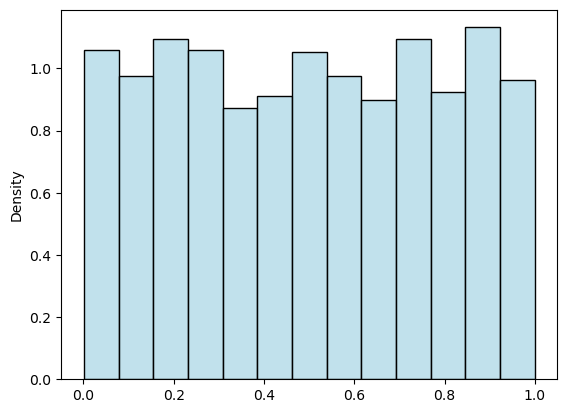

In [2]:
# generate 2000 random numbers from a uniform distribution
x= stats.uniform.rvs(size=2000) # stats.uniform.rvs geenerates random numbers from a uniform distribution
# plot histogram of the data
sns.histplot(x,stat='density', color='lightblue') # sns.histplot creates a histogram of the data with density normalization
plt.show()

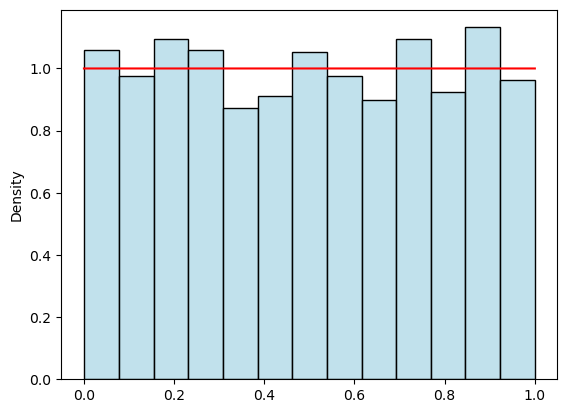

In [3]:
# plot density function to the plot 
sns.histplot(x,stat='density', color='lightblue') 
xvalues = np.linspace(0,1,2000)# generate 2000 evenly spaced numbers between 0 and 1
pdf= stats.uniform.pdf(xvalues) # calculate the probability density function of the uniform distribution
#at the xvalues
plt.plot(xvalues,pdf,color='red') # plot the pdf on the same graph as the histogram
plt.show()

## 2. Monte carlo simulation: Yatzi 

In [4]:
np.random.seed(123) # to make sure tht all answers are aligned
x1= np.random.randint(1,7,size=5) # generate 5 random integers between 1 and 6 
print(x1)

[6 3 5 3 2]


we could then count the number of ones and then count the remaining dice

In [5]:
count_ones1=np.sum(x1==1) # count the number of times 1 appears in x1
x2= np.random.randint(1,7,size=5-count_ones1) # roll remaining dice
print(x2)
count_ones2=np.sum(x2==1) # count the number of times 1 appears in x2
x3= np.random.randint(1,7,size=5-count_ones1-count_ones2) # roll remaining dice again
print(x3)
count_ones3=np.sum(x3==1) # count the number of times 1 appears in x3
score= count_ones1 + count_ones2 + count_ones3 # calculate the total score
print(score)


[4 3 4 2 2]
[1 2 2 1 1]
3


or we simulate the dice roll from a binomial distribition  where, p=1/6 
and n=5 in the first roll 
n-X1 in the second roll
n-X1-X2 in the third roll

In [6]:
# second way to do the same thing 
np.random.seed(321)
from scipy.stats import binom
x1= binom.rvs(n=5, p=1/6, size=1)
x2= binom.rvs(n=5-x1, p=1/6, size=1)
x3= binom.rvs(n=5-x1-x2, p=1/6, size=1)
print('After first roll: ',x1)
print('After second roll: ',x1+x2)
print('After third roll: ',x1+x2+x3)

After first roll:  [2]
After second roll:  [2]
After third roll:  [4]


turning this into a function!!

In [7]:
def play_round(num, n=5, p=1/6):
    x1= binom.rvs(n=5, p=p, size=1)
    x2= binom.rvs(n=5-x1, p=p, size=1)
    x3= binom.rvs(n=5-x1-x2, p=p, size=1)
    return (x1+x2+x3)*num 

In [8]:
print(play_round(1))

[2]


In [9]:
def play_game():
    total_score=0
    for i in range(1,7):
        total_score += play_round(i)
    return total_score
print('Game score: ', play_game())

Game score:  [34]


In [10]:
scores=np.array([play_game() for _ in range(10000)]) 
# simulate 1000 games and store the scores in an array

In [11]:
m=np.mean(scores) # calculate the mean of the scores
print('Expected score: ',m)

Expected score:  44.237


the probability of recieving a bonus (scores>= 63)

In [12]:
bonus_prob = np.mean(scores>= 63) # calculate the probability of getting a score of 63 or higher
print('Expected score: ', bonus_prob)

Expected score:  0.0432


plotting the distribution of the scores

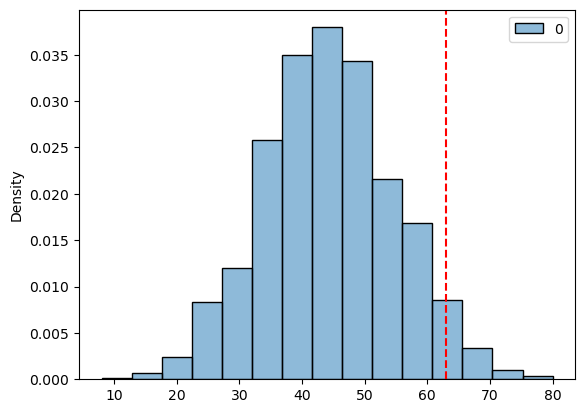

In [13]:
sns.histplot(scores,bins=15,stat='density', color='lightblue')
plt.axvline(63, color='red', linestyle='--')
plt.show()

# BOOTSTRAP!


In [14]:
import pandas as pd
import math
numbers = [183, 179, 179, 183, 178, 176, 182, 177, 180, 179]
vector = pd.Series(numbers)
print('Mean: ', vector.mean()) # calculate the mean of the numbers
print('Standard Deviation: ', vector.std()) # calculate the standard deviation of the numbers
print('Standard error:', vector.std()/math.sqrt(len(vector))) # calculate the standard error 

Mean:  179.6
Standard Deviation:  2.412928142780514
Standard error: 0.7630348761506397


## To sample randomly from the vector we use the following code!

In [17]:
np.random.seed(1234)
new_sample= vector.sample(3,replace=False)
print( new_sample)

7    177
2    179
9    179
dtype: int64


In [18]:
np.random.seed(123)
boot_samples=2000
boot_means=np.zeros(boot_samples) 
""" np.zeros()function creates a new NumPy array of a specified shape and data type, with all elements 
initialized to zero. In this case, it creates an array of length boot_samples (which is 2000) filled with
zeros. This array will be used to store the mean of each bootstrap sample. """
for i in range(boot_samples):
    boot_sample= vector.sample(len(vector), replace=True)
     # create a bootstrap sample by sampling with replacement
    boot_means[i]= boot_sample.mean() 
    # calculate the mean of the bootstrap sample and store it in the boot_means array
print(boot_means.std()) 
# calculate the standard deviation of the bootstrap means, which is an estimate of the 
# standard error of the mean!!!!

0.7292611997768702


## plot the distribution

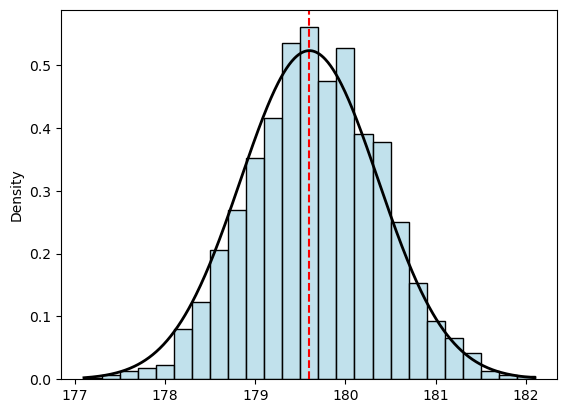

In [20]:
sns.histplot(boot_means, stat='density', color='lightblue', binwidth=0.2)
plt.axvline(vector.mean(), color='red', linestyle='--')

# add a normal denity curve to the plot
x=np.linspace(min(boot_means), max(boot_means), 500)
mu=vector.mean()
signma=sigma = np.std(vector, ddof=1)/np.sqrt(len(vector))
plt.plot(x,norm.pdf(x, mu, sigma), color='black',linewidth=2)
plt.show()


## MONTE CARLO-YouTube example

In [1]:
import numpy as np
sims=1000000
A=np.random.uniform(1,5,sims)
B=np.random.uniform(2,6,sims)
duration= A + B


The probability of you not making the party(duration above 9 hrs) is:  0.124777


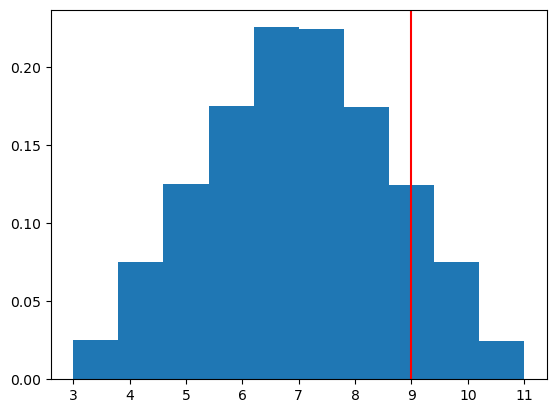

In [5]:
import matplotlib.pyplot as plt
plt.hist(duration, density=True)
plt.axvline(9,color='r')
print('The probability of you not making the party(duration above 9 hrs) is: ',(duration>9).sum()/sims)

## MODULE 1!!


In [ ]:
import pandas as pd
# Import numbers as vector: 
x = pd.Series((9.0, 5.4, 12.3, 6.6, 15.5, 7.0, 11.3, 6.6, 8.4, 14.4, 10.3, 13.2))
print('Mean: ', x.mean()) # calculate the mean of the numbers
print('Median: ', x.median()) # calculate the median of the numbers
print('Mode: ', x.mode()) # calculate the mode of the numbers
print('Standard Deviation: ', x.std()) # calculate the standard deviation of the numbers
print('quan')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/amandajotte/Library/CloudStorage/Dropbox/Mac/Documents/Data118Autum23/penguins_size.csv'